# Plots to create illustration of size coverage between CDP and CIP

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
from PIL import Image
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from notebooks.utils.plot_utils import add_sect

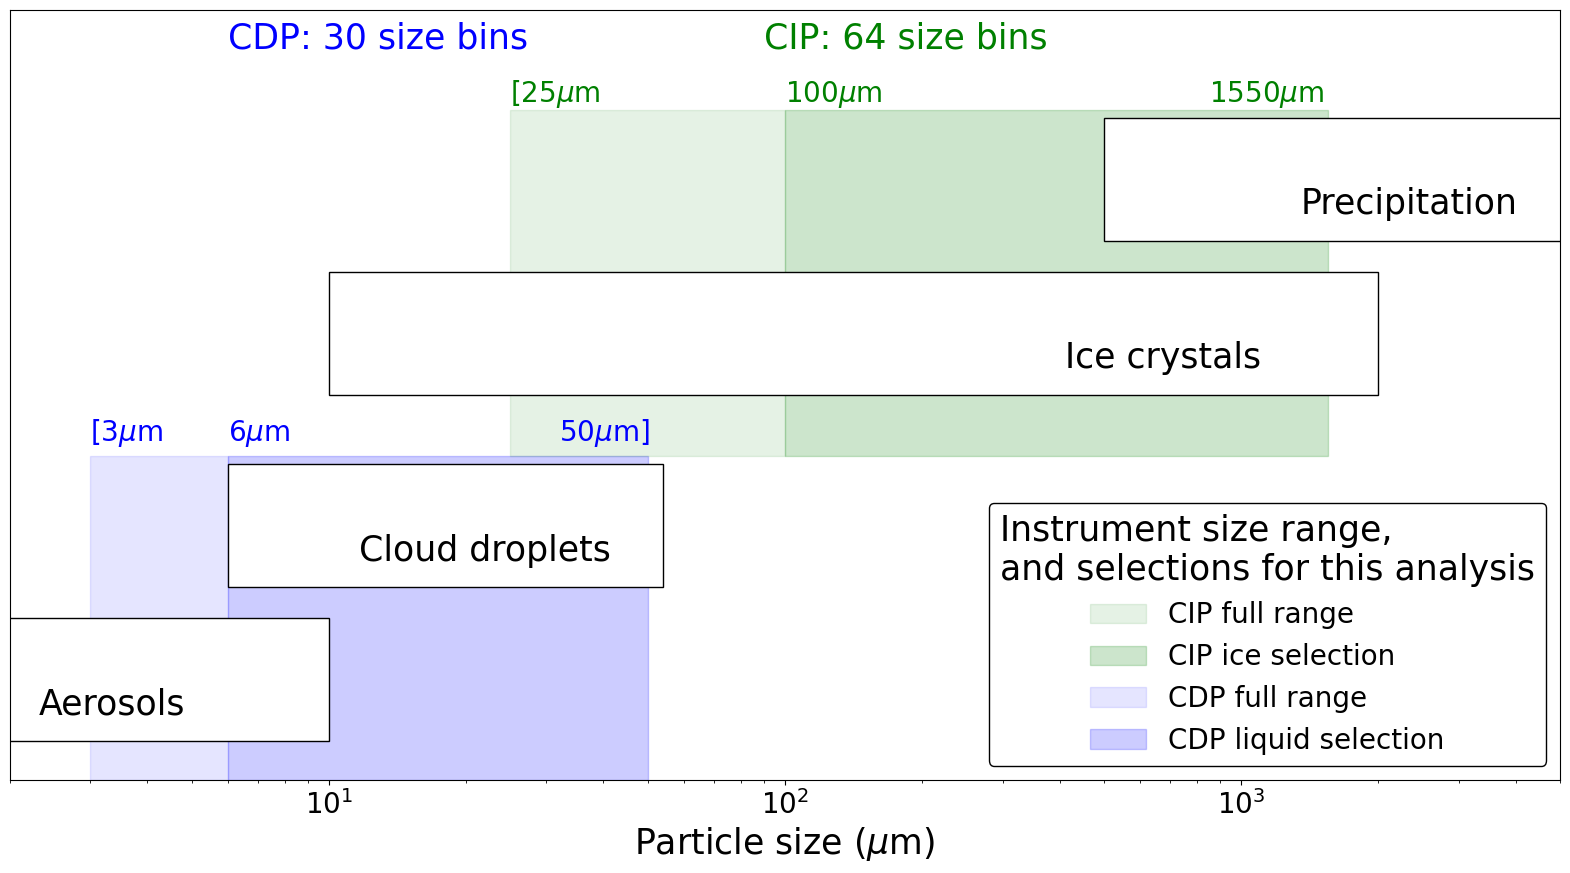

In [7]:
# create an empty plot

fig, ax = plt.subplots(figsize=(20,10))

hs=25
ss=20

# CDP span
ax.axvspan(3,6,0,0.42, color='b', alpha=0.1)
ax.axvspan(6,50,0,0.42, color='b', alpha=0.2)
ax.text(6,0.95,'CDP: 30 size bins',color='b', fontsize=hs)
ax.text(3,0.44,'[3$\mu$m', color='b',fontsize=ss)
ax.text(6,0.44,'6$\mu$m',color='b',fontsize=ss)
ax.text(32,0.44,'50$\mu$m]',color='b',fontsize=ss)

# CIP span
ax.axvspan(25,100,0.42,0.87, color='g', alpha=0.1)
ax.axvspan(100,1550,0.42,0.87, color='g', alpha=0.2)
#ax.axvspan(1550,1600,0.42,0.87, color='g', alpha=0.1)
ax.text(90,0.95,'CIP: 64 size bins',color='g', fontsize=hs)
ax.text(25,0.88,'[25$\mu$m',color='g', fontsize = ss)
ax.text(100,0.88,'100$\mu$m', color='g',fontsize=ss)
ax.text(850,0.88,'1550$\mu$m',color='g',fontsize=ss)
#ax.text(1560,0.88,'1600$\mu$m]',color='g',fontsize=ss)

# Proxy artist for legends for the CIP and CDP span
cip1_patch = plt.Rectangle((0, 0), 1, 1, color='g', alpha=0.1)
cip2_patch = plt.Rectangle((0, 0), 1, 1, color='g', alpha=0.2)
cdp1_patch = plt.Rectangle((0, 0), 1, 1, color='b', alpha=0.1)
cdp2_patch = plt.Rectangle((0, 0), 1, 1, color='b', alpha=0.2)

# Add legend
plt.legend([cip1_patch, cip2_patch,cdp1_patch, cdp2_patch],
           ['CIP full range', 'CIP ice selection','CDP full range', 'CDP liquid selection'], 
           loc='lower right', title='Instrument size range,\nand selections for this analysis', fontsize = ss ,title_fontsize=hs, 
           framealpha=1, edgecolor='black')

# Particle ranges
#aerosols
# Define properties for the boxes (x=10, 50 corresponds to log10)
# (x, y, width, height)
h=0.16 #height
aero = (0.01, 0.05, 10, h) # aerosols 0.01 to 10 microm
cloud = (6, 0.25, 48, h) # cloud droplet 2 to 50 micrometers
ice = (10, 0.50, 1990, h) # ice crystals 10 to 2000 micrometers
precip = (500, 0.70, 5500, h) # 500 micrometers to several cm

box_positions = [aero,cloud,ice, precip]  # (x, y, width)
texts = ['Aerosols', 'Cloud droplets', 'Ice crystals', 'Precipitation']

for (x, y, width, height), text in zip(box_positions, texts):
    # Create a rectangle box
    box = plt.Rectangle((x, y), width, height, facecolor='white', edgecolor='black')
    plt.gca().add_patch(box)
    
    # Annotate the box with text
    plt.text(x + width / 3, y + 0.035, text, horizontalalignment='center', fontsize=hs)

y_axis = ax.axes.get_yaxis()
y_axis.set_visible(False)

ax.set_xscale('log')  # Set x-axis to log scale
ax.set_xlim(2,5000)
plt.xticks(fontsize=ss)
ax.set_xlabel('Particle size ($\mu$m)', fontsize=hs)
plt.savefig('sizes.png',bbox_inches='tight',dpi=300)

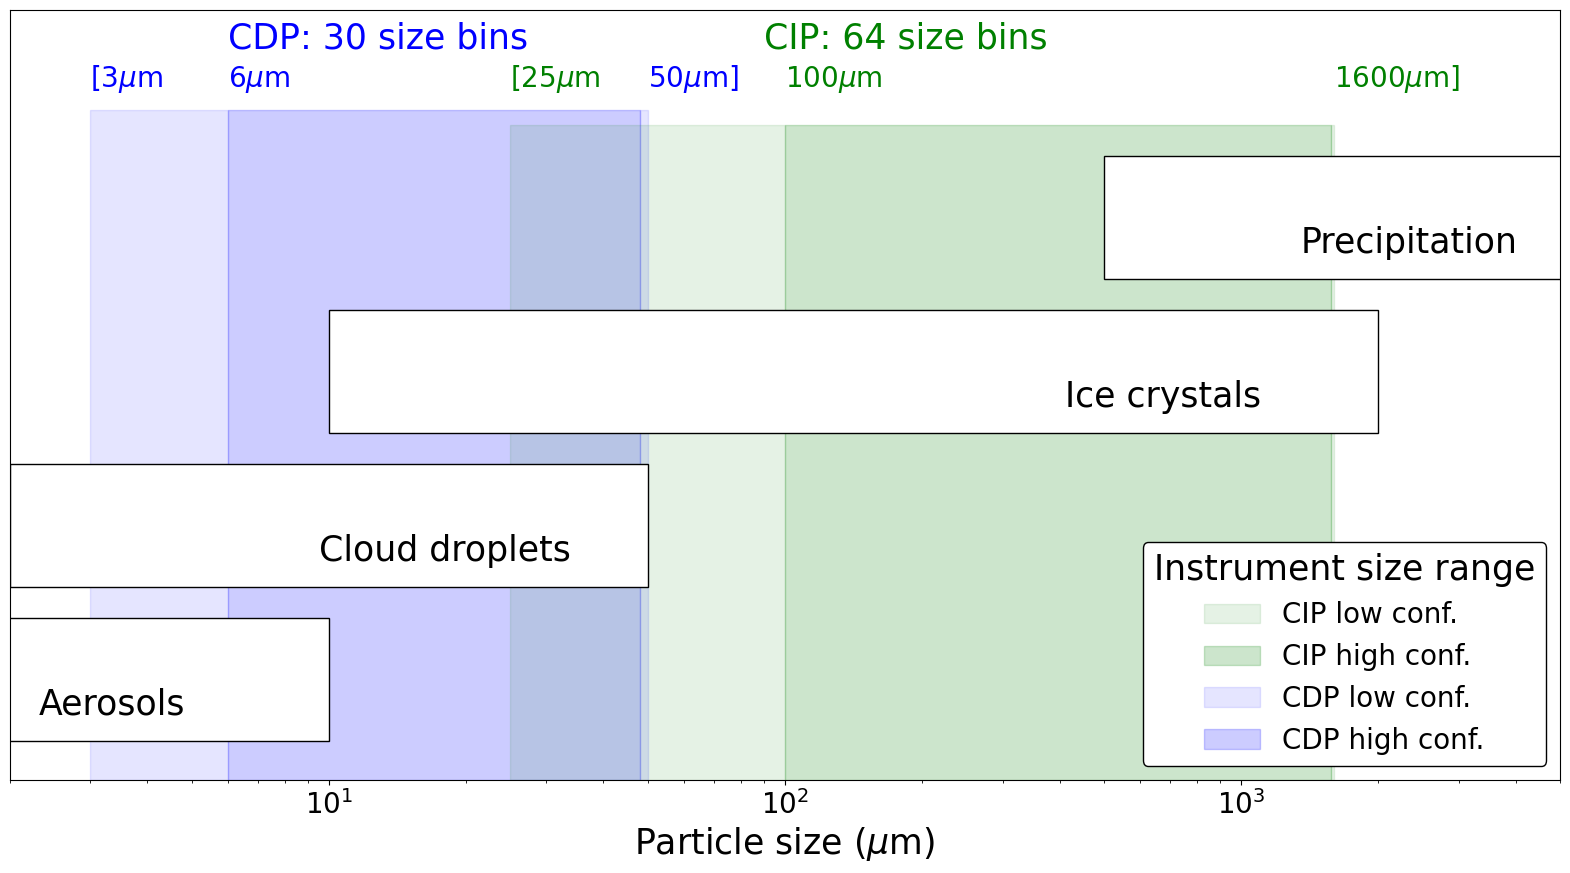

In [ ]:
# create an empty plot

fig, ax = plt.subplots(figsize=(20,10))

hs=25
ss=20

# CDP span
ax.axvspan(3,6,0,0.87, color='b', alpha=0.1)
ax.axvspan(6,48,0,0.87, color='b', alpha=0.2)
ax.axvspan(48,50,0,0.87, color='b', alpha=0.1)
ax.text(6,0.95,'CDP: 30 size bins',color='b', fontsize=hs)
ax.text(3,0.9,'[3$\mu$m', color='b',fontsize=ss)
ax.text(6,0.9,'6$\mu$m',color='b',fontsize=ss)
ax.text(50,0.9,'50$\mu$m]',color='b',fontsize=ss)

# CIP span
ax.axvspan(25,100,0,0.85, color='g', alpha=0.1)
ax.axvspan(100,1575,0,0.85, color='g', alpha=0.2)
ax.axvspan(1575,1600,0,0.85, color='g', alpha=0.1)
ax.text(90,0.95,'CIP: 64 size bins',color='g', fontsize=hs)
ax.text(25,0.9,'[25$\mu$m',color='g', fontsize = ss)
ax.text(100,0.9,'100$\mu$m', color='g',fontsize=ss)
ax.text(1600,0.9,'1600$\mu$m]',color='g',fontsize=ss)

# Proxy artist for legends for the CIP and CDP span
cip1_patch = plt.Rectangle((0, 0), 1, 1, color='g', alpha=0.1)
cip2_patch = plt.Rectangle((0, 0), 1, 1, color='g', alpha=0.2)
cdp1_patch = plt.Rectangle((0, 0), 1, 1, color='b', alpha=0.1)
cdp2_patch = plt.Rectangle((0, 0), 1, 1, color='b', alpha=0.2)

# Add legend
plt.legend([cip1_patch, cip2_patch,cdp1_patch, cdp2_patch],
           ['CIP low conf.', 'CIP high conf.','CDP low conf.', 'CDP high conf.'], 
           loc='lower right', title='Instrument size range', fontsize = ss ,title_fontsize=hs, 
           framealpha=1, edgecolor='black')

# Particle ranges
#aerosols
# Define properties for the boxes (x=10, 50 corresponds to log10)
# (x, y, width, height)
h=0.16 #height
aero = (0.01, 0.05, 10, h) # aerosols 0.01 to 10 microm
cloud = (2, 0.25, 48, h) # cloud droplet 2 to 50 micrometers
ice = (10, 0.45, 1990, h) # ice crystals 10 to 2000 micrometers
precip = (500, 0.65, 5500, h) # 500 micrometers to several cm

box_positions = [aero,cloud,ice, precip]  # (x, y, width)
texts = ['Aerosols', 'Cloud droplets', 'Ice crystals', 'Precipitation']

for (x, y, width, height), text in zip(box_positions, texts):
    # Create a rectangle box
    box = plt.Rectangle((x, y), width, height, facecolor='white', edgecolor='black')
    plt.gca().add_patch(box)
    
    # Annotate the box with text
    plt.text(x + width / 3, y + 0.035, text, horizontalalignment='center', fontsize=hs)

y_axis = ax.axes.get_yaxis()
y_axis.set_visible(False)

ax.set_xscale('log')  # Set x-axis to log scale
ax.set_xlim(2,5000)
plt.xticks(fontsize=ss)
ax.set_xlabel('Particle size ($\mu$m)', fontsize=hs)
plt.savefig('sizes.png',bbox_inches='tight')

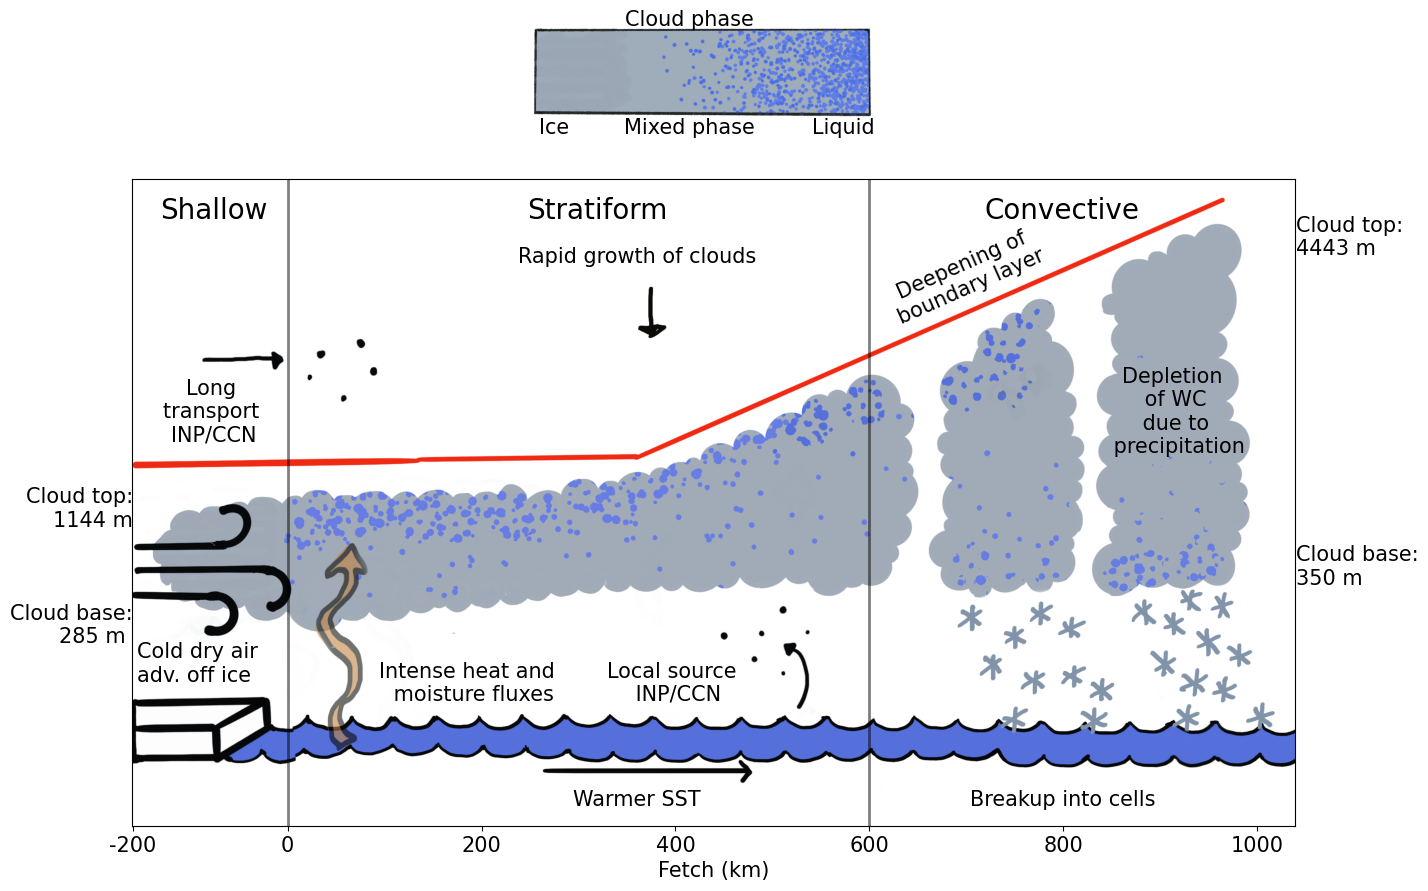

In [77]:
# plot with the conceptual model
conceptmod = 'ColdAirOutbreak.png'


fig, ax = plt.subplots(figsize=(15,20))
img = plt.imread(conceptmod)

imgplot = ax.imshow(img)

# set x axis ticks (fetch)
tick_positions = [0, 400, 900, 1400,1900, 2400,2900]
tick_labels = [-200,0,200,400,600,800,1000]
ax.set_xticks(tick_positions, labels=tick_labels, fontsize=15)

# set y-axis ticks (altitude)
#tick_positions = [0,280,560,840,1128,1400]
#tick_labels = [5000,4000,3000,2000,1000,0]
#tick_positions = [0,82,164,246,328,410,492,574,656,738,820,902,984,1066,1148,1230,1312,1394]
#tick_labels = [5100,4800,4500,4200,3900,3600,3300,3000,2700,2400,2100,1800,1500,1200,900,600,300,0]
#ax.set_yticks(tick_positions, labels=tick_labels, fontsize=15)
plt.yticks([])

add_sect(ax, x_vals=[0.07,0.4,0.8], xv_vals=[400,1900],fs=20)
ax.set_xlabel('Fetch (km)', fontsize=15) # set plot labels
#ax.set_ylabel('Altitude (m)', fontsize=15)

# add texts for figure
ax.text(210,600,"Long \ntransport \nINP/CCN", fontsize=15, horizontalalignment='center', verticalalignment='center')
ax.text(1400,1300,"Local source \n INP/CCN", fontsize=15, horizontalalignment='center', verticalalignment='center')
ax.text(10,1250,"Cold dry air\nadv. off ice ", fontsize=15, horizontalalignment='left', verticalalignment='center')
ax.text(2400,1600,"Breakup into cells", fontsize=15, horizontalalignment='center', verticalalignment='center')
ax.text(2150,250,"Deepening of\nboundary layer", fontsize=15, horizontalalignment='center', verticalalignment='center', rotation=24)
ax.text(1300,1600,"Warmer SST", fontsize=15, horizontalalignment='center', verticalalignment='center')
ax.text(1300,200,"Rapid growth of clouds", fontsize=15, horizontalalignment='center', verticalalignment='center')
ax.text(870,1300,"Intense heat and \n moisture fluxes", fontsize=15, horizontalalignment='center', verticalalignment='center')
#ax.text(1100,900,"Liquid cloud tops", fontsize=15, horizontalalignment='center', verticalalignment='center')
#ax.text(2050,800,"Glacification", fontsize=15, horizontalalignment='center', verticalalignment='center')
ax.text(2690,600, "Depletion \n of WC \n due to \n precipitation", fontsize=15, horizontalalignment='center', verticalalignment='center')

# cloud top and base at beginning and end
ax.text(0,850,"Cloud top:\n1144 m", fontsize=15, horizontalalignment='right', verticalalignment='center')
ax.text(0,1150, "Cloud base:\n285 m ", fontsize=15, horizontalalignment='right', verticalalignment='center')

ax.text(3000,150,"Cloud top:\n4443 m", fontsize=15, horizontalalignment='left', verticalalignment='center')
ax.text(3000,1000, "Cloud base:\n350 m ", fontsize=15, horizontalalignment='left', verticalalignment='center')

# --- Inset axis for the additional image ---
top_img = plt.imread("legend_concept.png")  # your extra image

# Create inset axis: width and height are fractions of the parent axis
# loc="upper center" (you can use 'upper left', 'upper right', etc.)
ax_inset = inset_axes(
    ax,
    width="50%",     # inset width as % of main axis
    height="20%",    # inset height as % of main axis
    loc="upper center",
    borderpad=-12,   # padding from the edge
)

ax_inset.imshow(top_img)
ax_inset.axis("off")   # remove ticks for inset image

# --- Annotate the inset image ---
ax_inset.text(680, -10,"Cloud phase",fontsize=15,ha="center",va="top")
ax_inset.text(680, 410,"Mixed phase",fontsize=15,ha="center",va="top")
ax_inset.text(100, 410,"Ice",fontsize=15,ha="left",va="top")
ax_inset.text(1400, 410,"Liquid",fontsize=15,ha="right",va="top")

plt.savefig('conceptimg.png',bbox_inches='tight',dpi=300)


plt.show()